# **SED CALIB**

Tests on a sed library with two degrees of freedom: alpha (normalisation) and Teff.

## **0. Initialisation**

### 0.1 Packages

In [193]:
### Libs ###
from imports import *

#custom
from src.download_bt_spectra import download_bt_spectra
import src.data_manipulations as dm; reload(dm)
import src.plot_tools as pt; reload(pt)
import src.photometry_errors as pe; reload(pe)
from src.format_to_dat import format_to_lephareinput 

#lephare
import lephare as lp
config = lp.default_stargal_config.copy()

base_dir = os.path.abspath(os.path.join(os.getcwd()))
sys.path.append(base_dir)

%matplotlib inline

### 0.2 Important inputs

In [194]:
n_sources = 50000 # Number of sources per template to sample
max_row_lephare = 500000 # Number of rows to loop on with zphota
work_with_absmags = False # If true, mag_obs --> mag_obs - deltam
return_dm = True # return dm in mock table
if work_with_absmags == True: #must be true in this case
    return_dm = True


#physical quantities of seds to download.
#WARNING: The number of seds downloaded is equal to len(teff_values) x len(logg_values) x (metallicity_values), 
#so it could need a lot of space!
#physical quantities
teff_values = 7200 #list(range(800, 12001, 100)) + list(range(13000, 20001, 1000)) + list(range(22000, 50001, 2000))
logg_values = np.arange(0.0, 5.6, 0.5)
metallicity_values = 0.0 #[-3, -2.5, -2, -1.5, -1, -0.5, 0.0, 0.5]

#if true, delete temporary files
clean_cache = True #lephare sedlib and maglib cache
clean_seds = False #local directory seds

### 0.3 Download spectra

Use ``download_bt_spectra.py``

In [195]:
#--- Downloading parameters --- 
#model
MODEL = "bt-nextgen-agss2009"
BASE_URL = f"https://svo2.cab.inta-csic.es/theory/newov2/ssap.php?model={MODEL}" #website to download from

#dl directory
sed_name = f"fullBTlib" #WARNING: name after fixed parameter
local_dir = f'data/tests/bt_spectra_{sed_name}' #directory where tests are saved 
OUTPUT_DIR = os.path.abspath(os.path.join(base_dir, "data/bt_spectra"))#directory to download in

#Control wavelength range and resolution
LMIN = 1145.0   # Å, set to None to keep full range
LMAX = 25005.0  # Å
DL   = 3.0      # Å, set to None to keep original sampling
wl_norm = 10000 # Å. Lot of space earned
make_sed_list = True # create sed list in the same folder
overwrite_seds = False # if true, overwrite identically named seds
list_name = f"bt_seds_{sed_name}"

#--- Download ---
download_bt_spectra(MODEL=MODEL, BASE_URL=BASE_URL, OUTPUT_DIR=OUTPUT_DIR,
    teff_values=teff_values, logg_values=logg_values, metallicity_values=metallicity_values,
    LMIN=LMIN, LMAX=LMAX, DL=DL, wl_norm=wl_norm,
    make_sed_list=make_sed_list, overwrite_seds=overwrite_seds, list_name=list_name, list_folder=f'{base_dir}/{local_dir}')

13627 <TR> lines found in VOTABLE.
11 spectra found matching with the chosen grid.
Starting parallel download with 8 workers...
[1/11] Skipping existing: Teff7200_logg3.5_FeH0.0.sed
[2/11] Skipping existing: Teff7200_logg3.0_FeH0.0.sed
[3/11] Skipping existing: Teff7200_logg1.5_FeH0.0.sed
[4/11] Skipping existing: Teff7200_logg5.0_FeH0.0.sed
[5/11] Skipping existing: Teff7200_logg4.5_FeH0.0.sed
[6/11] Skipping existing: Teff7200_logg0.0_FeH0.0.sed
[7/11] Skipping existing: Teff7200_logg4.0_FeH0.0.sed
[8/11] Skipping existing: Teff7200_logg0.5_FeH0.0.sed
[9/11] Skipping existing: Teff7200_logg2.5_FeH0.0.sed
[10/11] Skipping existing: Teff7200_logg2.0_FeH0.0.sed
[11/11] Skipping existing: Teff7200_logg1.0_FeH0.0.sed
All available spectrum have been downloaded and formated.
sed list written to  /home/hallouin/Documents/t_hall/lephare-u-Tototime-sedlib-calibration/calibration/data/tests/bt_spectra_fullBTlib/bt_seds_fullBTlib.list


## **1. Run first LePHARE steps**

In [196]:
filt_fname = "photozdc1"
sedlib_prefix = "BT_SEDs_"
maglib_prefix = "BT_LSST_"

### 1.0 Filter to lib (optional)

In [197]:
# # If you want to add more or less filters

# #--- With LSST filters ---
# filter_path = f"{base_dir}/data/filt" 

# filter_rep = lp.keyword("FILTER_REP", filter_path)
# filter_list = lp.keyword("FILTER_LIST",
# "BuzzardLSSTu.res,BuzzardLSSTg.res,BuzzardLSSTr.res,\
#      BuzzardLSSTi.res,BuzzardLSSTz.res,BuzzardLSSTy4.res,EUC_J.ecf")

# filterLib = lp.Filter(config_keymap={"FILTER_REP":filter_rep,
#                                    "FILTER_LIST":filter_list,
#                                    "TRANS_TYPE":lp.keyword("TRANS_TYPE", "0"),
#                                    "FILTER_CALIB":lp.keyword("FILTER_CALIB", "0"), #"0,0,0,0,0,0"
#                                    "FILTER_FILE":lp.keyword("FILTER_FILE", filt_fname)})


# filterLib.run()

### 1.1 Sed to Lib

In [198]:
#--- With BT ---
SED_list_path = f"{base_dir}/{local_dir}/{list_name}.list"
sedLib = lp.Sedtolib(config_keymap={
    "STAR_SED": lp.keyword("STAR_SED", SED_list_path),
    "STAR_FSCALE": lp.keyword("STAR_FSCALE", "3.432E-09"),
    "STAR_LIB": lp.keyword("STAR_LIB", f'{sedlib_prefix}{sed_name}')},)
    
sedLib.run(typ="S")

#######################################
# It s translating SEDs to binary library #
# with the following options :           
# Config file     : 
# Library type     : STAR
# STAR_SED    :/home/hallouin/Documents/t_hall/lephare-u-Tototime-sedlib-calibration/calibration/data/tests/bt_spectra_fullBTlib/bt_seds_fullBTlib.list
# STAR_LIB    :BT_SEDs_fullBTlib
# STAR_LIB doc:/home/hallouin/.cache/lephare/work/lib_bin/BT_SEDs_fullBTlib.doc
# STAR_FSCALE :3.432e-09
#######################################
Number of SED in the list 11


### 1.2 MagGal

In [199]:
maglib = lp.MagGal(config_keymap=lp.all_types_to_keymap(config))

star_lib_in = f"{sedlib_prefix}{sed_name}"
star_lib_out = f"{maglib_prefix}{sed_name}"
maglib.run(typ="S",
    star_lib_in=star_lib_in,
    star_lib_out=star_lib_out,
    filter_file=filt_fname,
    magtype="AB",
    mod_extinc="0",
    extinc_law="calzetti.dat",
    em_dispersion="0",
    lib_ascii="YES",
    z_step="0.0,0,0")

#######################################
# It s computing the SYNTHETIC MAGNITUDES #
# For Gal/QSO libraries with these OPTIONS #
# with the following options :           
# Config file     : 
# Filter file     : photozdc1
# Magnitude type     : AB
# COSMOLOGY   :70,0.3,0.7
# STAR_LIB_IN    :/home/hallouin/.cache/lephare/work/lib_bin/BT_SEDs_fullBTlib(.doc & .bin)
# STAR_LIB_OUT   :/home/hallouin/.cache/lephare/work/lib_mag/BT_LSST_fullBTlib(.doc & .bin)
# LIB_ASCII   YES
# CREATION_DATE Wed Apr 15 18:37:23 2026
#############################################


## **2. Make mock catalog from mag lib**

### 2.1 Load magbin into pandas and sed physical data

In [200]:
#--- copy-paste maglib from the lepahre cache folder ---
from pathlib import Path
import shutil
cache_dir = Path.home() / f".cache/lephare/work" 
paste_path = f"{base_dir}/{local_dir}/"
shutil.copy(f"{cache_dir}/lib_mag/{star_lib_out}.dat", paste_path)

'/home/hallouin/Documents/t_hall/lephare-u-Tototime-sedlib-calibration/calibration/data/tests/bt_spectra_fullBTlib/BT_LSST_fullBTlib.dat'

In [201]:
#--- Convert to pandas ---
maglib = dm.maglib_to_pandas(f"{base_dir}/{local_dir}/{star_lib_out}.dat")

#--- Generate sed grid with associated physical values from names ---
sed_grid_path = f'{base_dir}/{local_dir}/{list_name}.list'
sed_grid_init = dm.SED_GRID(sed_grid_path)
sed_grid = sed_grid_init.build(sort_values=True)
sed_grid[:,0] = sed_grid[:,0] + 1
sed_grid = pd.DataFrame(sed_grid, columns=["model", "teff", "logg", "feh"])

#--- Merge in the one table from which we generate mock mags ---
maglib = dm.join_tables(maglib, (sed_grid, "model", "model")).sort_values(["teff", "logg", "feh"]).reset_index(drop=True)
maglib[:3]

,model,N_filt,magnitude_u,magnitude_g,magnitude_r,magnitude_i,magnitude_z,magnitude_y,teff,logg,feh
0,1.0,6.0,-0.677537,-1.44315,-1.42139,-1.28144,-1.30244,-1.27131,7200.0,0.0,0.0
1,2.0,6.0,-0.646449,-1.44388,-1.40650,-1.27311,-1.28291,-1.26785,7200.0,0.5,0.0
2,3.0,6.0,-0.596321,-1.42396,-1.40385,-1.28199,-1.26940,-1.26420,7200.0,1.0,0.0


In [202]:
# # --- Charger les données ---
# data = maglib[["magnitude_u", "magnitude_g", "magnitude_r", "magnitude_i", "magnitude_z", "magnitude_y", "logg"]]

# filters = ["u", "g", "r", "i", "z", "y"]

# # --- Conversion en flux ---
# for f in filters:
#     data[f+"_flux"] = 10**(-0.4 * data[f"magnitude_{f}"])

# # --- Calcul de ΔF / ΔTeff ---
# delta_results = {}

# for f in filters:
#     F = data[f+"_flux"].values
#     Teff = data["logg"].values
    
#     dF = np.diff(F)
#     dT = np.diff(Teff)
    
#     dF_dT = dF / dT  # dérivée discrète
    
#     delta_results[f] = dF_dT

# # --- Affichage ---
# for f in filters:
#     print(f"{f}: dF/dT = {delta_results[f]}")
    
# %matplotlib inline
# plt.figure()
# plt.plot(maglib["logg"][:-1], delta_results["y"])
# plt.show()

### 2.2 Generate sources

In [203]:
#--- Class to sample sources and apply errors ---
class MockPhotometry:        
    @staticmethod
    def generate_sources_from_magabs(mags, ref_index, mag_min, mag_max, N, method="uniform", return_dm=False):
        """
        Generates N sources from a SED in magnitudes, with the reference band
        uniformly distributed between mag_min and mag_max. The other bands are
        shifted to preserve colors.
        """
        mags = np.array(mags)
        Nband = len(mags)
        if method == 'uniform':
            ref_mags = np.random.uniform(low=mag_min, high=mag_max, size=N)
            delta_M = ref_mags - mags[ref_index]
            sources = mags[None, :] + delta_M[:, None]
        else:
            raise NotImplementedError(f"Method '{method}' not implemented yet")
        if return_dm == True:
            return sources, delta_M[:, None]
        else:
            return sources

    @staticmethod
    def generate_sources_from_table(table, mag_cols, ref_index, mag_min, mag_max, N_per_star, 
                                    method="uniform", return_full_table=False, return_dm=False):
        """
        Generates mock sources for each source from a Pandas table.
        """
        mock_list = []

        for _, row in table.iterrows():
            mags = row[mag_cols].values
            mock_mags = MockPhotometry.generate_sources_from_magabs(mags, ref_index, mag_min, mag_max, N_per_star, method, return_dm)

            if return_dm == True:
                sources = mock_mags[0]
                sources_dm = mock_mags[1]
                df_sources = pd.DataFrame(np.concat((sources,sources_dm), axis=1), columns=np.concat((mag_cols,["mag_dm"])))
            else:
                sources = mock_mags
                df_sources = pd.DataFrame(sources, columns=mag_cols)

            if return_full_table:
                # dupliquer les autres colonnes
                other_cols = row.drop(labels=mag_cols)
                df_other = pd.DataFrame([other_cols.values]*N_per_star, columns=other_cols.index)

                df_sources = pd.concat([df_other.reset_index(drop=True),
                                        df_sources.reset_index(drop=True)],
                                        axis=1)

            mock_list.append(df_sources)

        df_mock = pd.concat(mock_list, ignore_index=True)

        return df_mock
    
    @staticmethod
    def sample_obs_mags_empiricalmodel(table, mag_cols, models=None, model_names=None, suffix="_err_sim", nsr_cut=None, error_factor=1,
                resample_errors=True, random_state=None, format="MMEE", add_errors=True, keep_true_mags=True, default_error_value=None):
        """ 
        Generate photometric errors using PhotometricErrorModel and optionally
        add Gaussian noise to magnitudes.
        """
        if error_factor is not None:
            error_factor = np.array(error_factor) if isinstance(error_factor, list) else error_factor
            
        if default_error_value is not None:
            table_with_errs = table.copy()
            for col in mag_cols:
                table_with_errs[col + suffix] = np.full(len(table_with_errs), default_error_value)
                
            if add_errors:
                #sample noisy cols
                rng = np.random.default_rng(random_state)
                mags = table_with_errs[mag_cols].to_numpy(dtype=float)
                err_cols = [c + suffix for c in mag_cols]
                sigmas = table_with_errs[err_cols].to_numpy(dtype=float)
                noise = rng.normal(loc=0.0, scale=sigmas)
                mags_obs = mags + noise
                #add to table
                table_with_errs[mag_cols] = mags_obs
                table_with_errs[err_cols] = sigmas

            if keep_true_mags:
                true_cols = [c + "_true" for c in mag_cols]
                table_with_errs[true_cols] = mags

            return table_with_errs

        # Generate errors
        table_with_errs = pe.PhotometricErrorModel().sample_errors_on_catalog(table, 
            mag_columns=mag_cols, models=models, model_names=model_names, format=format, suffix=suffix)
        if add_errors==False:
            return table_with_errs

        rng = np.random.default_rng(random_state)
        mags = table_with_errs[mag_cols].to_numpy(dtype=float)
        err_cols = [c + suffix for c in mag_cols]
        sigmas = table_with_errs[err_cols].to_numpy(dtype=float)*error_factor

        # Gaussian noise
        # convert to flux before adding gaussian noise
        fluxes = 10**(-0.4*mags)
        f_err = np.log(10)/2.5*fluxes*sigmas
        noise = rng.normal(loc=0.0, scale=f_err)
        f_obs = fluxes + noise
        mags_obs = -2.5*np.log10(f_obs)
        
        if nsr_cut is not None:
            mask_low_snr = nsr_cut < sigmas/mags_obs
            mags_obs[mask_low_snr] = np.nan
            sigmas[mask_low_snr] = np.nan
            
        table_with_errs[mag_cols] = mags_obs
        table_with_errs[err_cols] = sigmas

        if resample_errors ==True:
            table_with_errs = table_with_errs.drop(columns=err_cols)
            table_with_errs = pe.PhotometricErrorModel().sample_errors_on_catalog(table_with_errs, 
                mag_columns=mag_cols, models=models, model_names=model_names, format=format, suffix=suffix)
            if nsr_cut is not None:
                mask = (table_with_errs[err_cols]/table_with_errs[mag_cols] > nsr_cut).any(axis=1)
                table_with_errs.loc[mask, mag_cols + err_cols] = np.nan


        if keep_true_mags:
            true_cols = [c + "_true" for c in mag_cols]
            table_with_errs[true_cols] = mags

        return table_with_errs

    @staticmethod
    def sample_gaussian_errors(table, columns, sigmas, floors, suffix="_err_sim", err_columns=None, 
                            format="MMEE", random_state=None, inp_type="mag"):
        """
        Sample photometric errors for each specified column.
        """

        rng = np.random.default_rng(random_state)
        table = table.copy()
        n_cols = len(columns)
        n_rows = len(table)

        # --- format ---
        if np.isscalar(sigmas):
            sigmas = [sigmas] * n_cols
        if np.isscalar(floors):
            floors = [floors] * n_cols
        sigmas = np.array(sigmas, dtype=float)
        floors = np.array(floors, dtype=float)

        # --- error model ---
        f_err = np.broadcast_to(floors, (n_rows, n_cols))
        fluct = rng.normal(loc=0, scale=sigmas, size=f_err.shape)
        f_err = f_err + np.abs(fluct)
        # f_err = np.clip(f_err + fluct, f_err, None)

        # --- convert ---
        mags = table[columns].to_numpy(dtype=float)
        fluxes = 10**(-0.4 * mags)
        if inp_type == "mag":
            errors = 2.5 / np.log(10) * f_err / fluxes
        elif inp_type == "flux":
            for i, col in enumerate(columns):
                table[col] = fluxes[:, i]
            errors = f_err
        else:
            raise NotImplementedError("inp_type must be 'flux' or 'mag'")

        # --- add columns ---
        if suffix is not None:
            err_cols = [c + suffix for c in columns]
            if err_columns is not None:
                table = table.drop(columns=err_columns)
                Warning.warn("suffix and err_cols are specified. Overwriting err_cols.")
        elif err_columns is not None and suffix is None:
            err_cols = err_columns
        else: 
            raise ValueError("At least suffix or err_cols must be specified")
            
        for i, col in enumerate(err_cols):
            table[col] = errors[:, i]

        # --- gestion du format de sortie ---
        if format == "MMEE":
            ordered_cols = (columns + err_cols + [c for c in table.columns if c not in columns + err_cols] )
            out = table[ordered_cols]
        elif format == "MEME":
            interleaved = []
            for m, e in zip(columns, err_cols):
                interleaved += [m, e]
            other = [c for c in table.columns if c not in interleaved]
            out = table[interleaved + other]
        elif format == "end":
            out = table
        else:
            raise ValueError("format must be 'MMEE', 'MEME' or 'end'")

        return out

    @staticmethod
    def sample_obs_mags_gaussianmodel(table, mag_cols, sigmas, floors=0, suffix="_err_sim", err_columns=None, inp_type="mag", nsr_cut=None,
        error_factor=1, random_state=None, format="MMEE", add_errors=True, keep_true_mags=True, default_error_value=None, resample_errors=True):
        """ 
        Generate photometric errors using PhotometricErrorModel and optionally
        add Gaussian noise to magnitudes.
        """
        if error_factor is not None:
            error_factor = np.array(error_factor) if isinstance(error_factor, list) else error_factor

        # Generate errors
        table_with_errs = MockPhotometry.sample_gaussian_errors(table, mag_cols, sigmas, floors, 
            suffix=suffix, err_columns=err_columns, format=format, random_state=random_state, inp_type=inp_type)
        if not add_errors:
            return table_with_errs

        rng = np.random.default_rng(random_state)
        mags = table_with_errs[mag_cols].to_numpy(dtype=float)
        err_cols = [c + suffix for c in mag_cols]
        mags_err = table_with_errs[err_cols].to_numpy(dtype=float)*error_factor
        # Gaussian noise
        # convert to flux before adding gaussian noise
        fluxes = 10**(-0.4*mags)
        f_err = np.log(10)/2.5*fluxes*mags_err
        noise = rng.normal(loc=0.0, scale=f_err)
        f_obs = fluxes + noise

        mags_obs = -2.5*np.log10(f_obs)

        if nsr_cut is not None:
            mask_low_snr = nsr_cut < mags_err/mags_obs
            mags_obs[mask_low_snr] = np.nan
            mags_err[mask_low_snr] = np.nan

        table_with_errs[mag_cols] = mags_obs
        
        if resample_errors ==True:
            table_with_errs = MockPhotometry.sample_gaussian_errors(table_with_errs, mag_cols, sigmas, floors, 
            suffix=None, err_columns=err_cols, format=format, random_state=random_state, inp_type=inp_type)
            if nsr_cut is not None:
                mask = (table_with_errs[err_cols]/table_with_errs[mag_cols] > nsr_cut).any(axis=1)
                table_with_errs.loc[mask, mag_cols + err_cols] = np.nan
        else:
            table_with_errs[err_cols] = mags_err

        if keep_true_mags:
            true_cols = [c + "_true" for c in mag_cols]
            table_with_errs[true_cols] = mags

        return table_with_errs


In [204]:
#--- Sampling sources from only one source of the list ---
maglib_reduced = maglib.loc[maglib["logg"]==2.5]
maglib_reduced

,model,N_filt,magnitude_u,magnitude_g,magnitude_r,magnitude_i,magnitude_z,magnitude_y,teff,logg,feh
5,6.0,6.0,-0.55156,-1.36012,-1.4098,-1.32715,-1.25962,-1.25863,7200.0,2.5,0.0


In [205]:
mock_mags = MockPhotometry.generate_sources_from_table(table=maglib_reduced, #panda table
    mag_cols=['magnitude_u','magnitude_g','magnitude_r','magnitude_i','magnitude_z','magnitude_y'], #mag cols
    ref_index=2, #mag col ref
    mag_min=20, #minimum mag col ref
    mag_max=26, #maximum mag col ref
    N_per_star=n_sources, #n source per row
    method='uniform', #sampling method
    return_full_table=True,
    return_dm=return_dm)

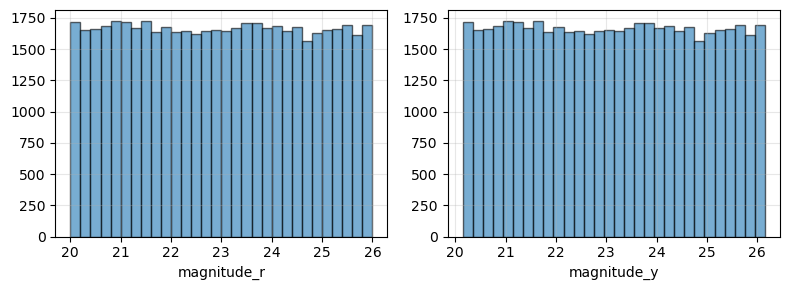

In [206]:
pt.plot_histograms(mock_mags, ["magnitude_r", "magnitude_y"], alpha=0.6, edgecolor="k")

### 2.3 Generate errors and observed mags

Here we generate errors from a gamma error model function of magnitude, made from DP1 error distribution.

Note: the model is quite limited in high/low luminosity due ot lack of sources in the original file.

In [207]:
dp1_ECDFS = pd.read_csv(f"{base_dir}/data/catalogs/DP1_ECDFS_photometry.csv")
dp1_ECDFS = dp1_ECDFS[(dp1_ECDFS["u_cModelMag"]<26.5) & (dp1_ECDFS["g_cModelMag"]<26.5) & (dp1_ECDFS["r_cModelMag"]<26.5) 
                        & (dp1_ECDFS["i_cModelMag"]<26.5) & (dp1_ECDFS["z_cModelMag"]<26.5) & (dp1_ECDFS["y_cModelMag"]<26.5)]

Make error model

In [208]:
# pem_dp1_ECDFS = pe.PhotometricErrorModel()

# dp1_ECDFS_models = pem_dp1_ECDFS.model_collection(
#     x_lists=dp1_ECDFS[["u_cModelMag","g_cModelMag","r_cModelMag","i_cModelMag","z_cModelMag","y_cModelMag"]], #mag list or panda.series
#     sigma_lists=dp1_ECDFS[["u_cModelMagErr","g_cModelMagErr","r_cModelMagErr","i_cModelMagErr","z_cModelMagErr","y_cModelMagErr"]], #mag err list or panda.series
#     model_names=["u", "g", "r", "i", "z", "y"], #model name list
#     sharpness_factor=1.05, #lower queue length of the gamma distribution
#     delta_mag=0.01, #bin length in magnitude
#     min_per_bin=200, #minimum per bin in mag, to avoid poorly populated bins
#     )

#--- Generate errors ---
#from DP1 mags
# mock_cat = MockPhotometry.sample_obs_mags_empiricalmodel(mock_mags, 
#     mag_cols = ['magnitude_u','magnitude_g','magnitude_r','magnitude_i','magnitude_z','magnitude_y'],
#     models = dp1_ECDFS_models, #model dict
#     model_names = ["u", "g", "r", "i", "z", "y"], #model name to use for each column
#     format="MEME", #output column order
#     error_cut=None,
#     default_error_value=None, #if you want same error for each source
#     add_errors=True, #sample observed mags
#     resample_errors=True)

Apply

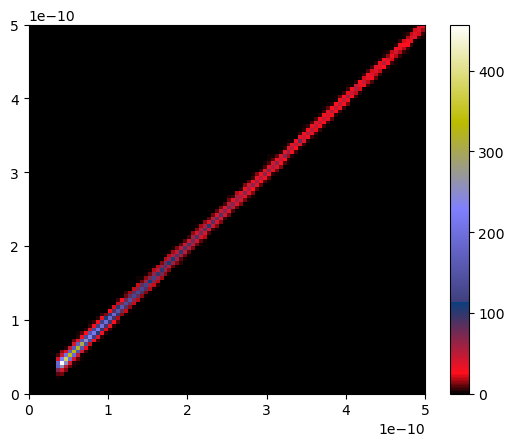

In [209]:
#--- Generate errors ---
#from fluxes
mock_cat = MockPhotometry.sample_obs_mags_gaussianmodel(mock_mags, 
        ['magnitude_u','magnitude_g','magnitude_r','magnitude_i','magnitude_z','magnitude_y'], 
        sigmas = [1.2e-11, 2e-12, 2e-12, 4e-12, 1e-11, 5e-11], floors = [2e-11, 3e-12, 3.5e-12, 6.5e-12, 1.2e-11, 8e-11], 
        suffix="_err_sim", err_columns=None, resample_errors=False,
        inp_type="mag", nsr_cut=10, error_factor= [0.1,1,1,1,1,1], add_errors=True, #[0.5,5,5,2,0.5,0.1]
        format="MEME", random_state=None, keep_true_mags=True, default_error_value=None)

band = "g"
# mock_cat = mock_cat[(mock_cat[f"magnitude_{band}_true"]<28)]
mags_true = mock_cat[f"magnitude_{band}_true"]
mags = mock_cat[f"magnitude_{band}"]
mags_err = mock_cat[f"magnitude_{band}_err_sim"]
# mags_true = dp1_ECDFS[f"{band}_cModelMag"]
# mags = dp1_ECDFS[f"{band}_cModelMag"]
# mags_err = dp1_ECDFS[f"{band}_cModelMagErr"]

plt.figure()

fluxes_true = 10**(-0.4*mags_true)
fluxes = 10**(-0.4*mags)
fluxes_err = np.log(10)/2.5*fluxes*mags_err
plt.hist2d(fluxes_true, fluxes, bins=100, cmap="gist_stern", range=((0,0.5e-9),(0,0.5e-9)))
# plt.scatter(fluxes_true, fluxes, s=1, alpha=0.2, c='w')

# plt.hist2d(mags_true, mags, bins=100, cmap="gist_stern", range=((19,27),(19,26)))
# plt.scatter(mags_true, mags, s=1)
# plt.plot([19.9,26.1],[19.9,26.1],c='w')
# plt.gca().invert_xaxis()
# plt.gca().invert_yaxis()

# plt.hist2d(mags, mags_err, bins=200, cmap="gist_stern", range=((19,27),(0,2)))
# plt.scatter(mags, mags_err, s=1, c='w')

plt.colorbar()
plt.show()

<Figure size 640x480 with 0 Axes>

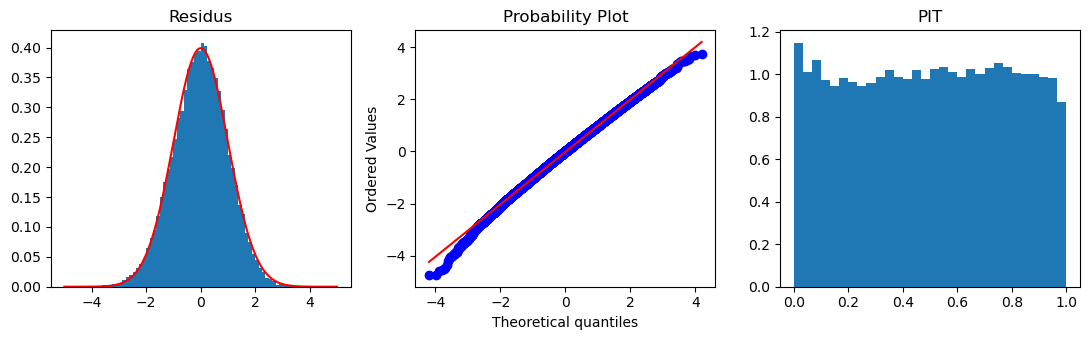

In [210]:
plt.figure()
r = (fluxes-fluxes_true)/fluxes_err#[(fluxes_err<0.15e-9) & (fluxes_err>0.95e-10)]
pt.plot_r_stats(r, density=True, rrange=(-5,5))
plt.show()

In [211]:
mags = mock_cat[["magnitude_u", "magnitude_g", "magnitude_r",
                     "magnitude_i", "magnitude_z", "magnitude_y"]].values
mags_err = mock_cat[["magnitude_u_err_sim", "magnitude_g_err_sim", "magnitude_r_err_sim",
                     "magnitude_i_err_sim", "magnitude_z_err_sim", "magnitude_y_err_sim"]].values

fluxes = 10**(-0.4*mags)
fluxes_err = np.log(10)/2.5*fluxes*mags_err

mag_dm = mock_cat["mag_dm"]

In [219]:
mabs_a = np.array(maglib[["magnitude_u", "magnitude_g", "magnitude_r", "magnitude_i", "magnitude_z", "magnitude_y"]].iloc[4].values)
mabs_b = np.array(maglib[["magnitude_u", "magnitude_g", "magnitude_r", "magnitude_i", "magnitude_z", "magnitude_y"]].iloc[5].values)
Fa = 10**(-0.4*(mabs_a + np.mean(mag_dm)))
Fb = 10**(-0.4*(mabs_b + np.mean(mag_dm)))

L=0
for i in range(6):
    ferr = fluxes_err[:, i][~np.isnan(fluxes_err[:, i])]
    L += np.abs(Fa[i] - Fb[i])**2/np.mean(ferr)**2

print(L)
keff = 6 - ((2 + L**2)/(1+L**2))
print(keff)

27.847656845540243
4.998712156711753


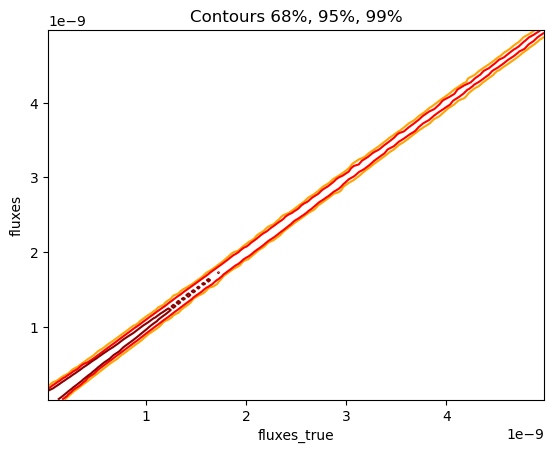

In [82]:
H, xedges, yedges = np.histogram2d(fluxes_true, fluxes, bins=100, range=((0, 0.5e-8), (0, 0.5e-8)))

H = H / np.sum(H)
H_flat = H.flatten()
indices = np.argsort(H_flat)[::-1]
H_sorted = H_flat[indices]
cumsum = np.cumsum(H_sorted)

levels = []
for p in [0.68, 0.95, 0.99]:
    idx = np.where(cumsum >= p)[0][0]
    levels.append(H_sorted[idx])
levels = np.sort(levels)

xcenters = (xedges[:-1] + xedges[1:]) / 2
ycenters = (yedges[:-1] + yedges[1:]) / 2
X, Y = np.meshgrid(xcenters, ycenters)

plt.contour(X, Y, H.T, levels=levels, colors=['orange', 'red', 'darkred', 'black'])
plt.xlabel("fluxes_true")
plt.ylabel("fluxes")
plt.title("Contours 68%, 95%, 99%")
plt.show()

In [83]:
#--- Optional: Revert to absolute magnitudes ---
if work_with_absmags==True:
    mag_cols = [f"magnitude_{f}" for f in 'ugrizy']
    mag_true_cols = [f"magnitude_{f}_true" for f in 'ugrizy']
    mock_cat[mag_cols] = mock_cat[mag_cols].subtract(mock_cat['mag_dm'], axis=0)
    mock_cat[mag_true_cols] = mock_cat[mag_true_cols].subtract(mock_cat['mag_dm'], axis=0)

mock_cat[:3]

,magnitude_u,magnitude_u_err_sim,magnitude_g,magnitude_g_err_sim,magnitude_r,magnitude_r_err_sim,magnitude_i,magnitude_i_err_sim,magnitude_z,magnitude_z_err_sim,...,teff,logg,feh,mag_dm,magnitude_u_true,magnitude_g_true,magnitude_r_true,magnitude_i_true,magnitude_z_true,magnitude_y_true
0,21.829128,0.008389,21.208813,0.001413,21.089951,0.001606,21.115159,0.002735,21.173827,0.005808,...,7200.0,4.5,-1.0,22.480390,21.839167,21.210760,21.092440,21.114010,21.185210,21.222820
1,23.896473,0.067352,23.185714,0.007625,23.065436,0.010201,23.069518,0.014585,23.147761,0.025435,...,7200.0,4.5,-1.0,24.452721,23.811498,23.183091,23.064771,23.086341,23.157541,23.195151
2,21.595192,0.006836,20.960472,0.001098,20.841491,0.001147,20.863261,0.002087,20.934181,0.008548,...,7200.0,4.5,-1.0,22.230256,21.589033,20.960626,20.842306,20.863876,20.935076,20.972686


In [84]:
#--- Save mock catalog to csv ---
mock_cat.to_csv(f"{base_dir}/{local_dir}/{sed_name}_mock.csv", index=False)

## 3. **zphota**

### 3.1 Convert mock to lephare input

In [85]:
#--- Run if no Ids in your table ---
def add_ids(df, base_id):
    n = len(df)
    width = len(str(n-1))
    df.insert(0, "mock_id", 0)
    df["mock_id"] = str(base_id) + pd.Series(range(n)).astype(str).str.zfill(width)
    
    return df

cat_path = f"{base_dir}/{local_dir}/{sed_name}_mock.csv"
temp = pd.read_csv(cat_path)
temp = add_ids(temp, 123456)
temp.to_csv(cat_path, index=False)

In [86]:
#--- Transfrom csv formated catalog to .dat, valid for lephare ---
csv_in = f"{base_dir}/{local_dir}/{sed_name}_mock.csv"
dat_out = f"{base_dir}/{local_dir}/{sed_name}_mock.dat"

#--- csv cols to use. To be set in right order ---
input_columns = ['mock_id', 
    'magnitude_u', 'magnitude_g', 'magnitude_r', 'magnitude_i', 'magnitude_z', 'magnitude_y',
    'magnitude_u_err_sim', 'magnitude_g_err_sim', 'magnitude_r_err_sim', 'magnitude_i_err_sim', 'magnitude_z_err_sim', 'magnitude_y_err_sim']

format_to_lephareinput(CAT_IN=csv_in,
    CAT_OUT=dat_out,
    input_columns=input_columns,
    n_filters=6,
    CAT_TYPE='long', #short = ident + mags +errmags, long += context + zspec
    simple_convert=False,
    apply_context = 'yes', #compute lephare context from non-valid columns
    facticious_specz = 0., #add/replace same specz value for all source
    shuffle=False,
    max_rows=None,
    error_value_state='default' #If default, nan --> 99
    )

[INFO] Added missing 'context' column automatically.
[INFO] Replacing 895 missing values with 99.0
[INFO] Added constant spec-z column with value 0.0
[OK] Catalog saved → /home/hallouin/Documents/t_hall/lephare-u-Tototime-sedlib-calibration/calibration/data/tests/bt_spectra_fullBTlib/fullBTlib_mock.dat


### 3.2 Prepare

In [87]:
config.update({
        "ZPHOTLIB": f"{maglib_prefix}{sed_name}",
        "SPEC_OUT": "NO",
        "CAT_IN": dat_out,
        "INP_TYPE": "M",
        "CAT_TYPE": "LONG",
        "CAT_MAG": "AB",
        "PARA_OUT": f"{base_dir}/stargal_output.para",
        "CAT_OUT": f"{base_dir}/{local_dir}/{sed_name}_mock.out",
        "AUTO_ADAPT": "NO",
        "PDZ_TYPE": "MIN_ZG",
        "CAT_FMT": "MMEE",
        "ERR_SCALE": 0,
        "SPEC_OUT": "NO",
        "CHI2_OUT": "NO",
        "RM_DISCREPENT": 1e9,
    })

zphota = lp.PhotoZ(lp.all_types_to_keymap(config))

####################################### 
# PHOTOMETRIC REDSHIFT with OPTIONS   # 
# Config file            : 
# CAT_IN                 : /home/hallouin/Documents/t_hall/lephare-u-Tototime-sedlib-calibration/calibration/data/tests/bt_spectra_fullBTlib/fullBTlib_mock.dat
# CAT_OUT                : /home/hallouin/Documents/t_hall/lephare-u-Tototime-sedlib-calibration/calibration/data/tests/bt_spectra_fullBTlib/fullBTlib_mock.out
# CAT_LINES              : 0 1000000000
# PARA_OUT               : /home/hallouin/Documents/t_hall/lephare-u-Tototime-sedlib-calibration/calibration/stargal_output.para
# INP_TYPE               : M
# CAT_FMT[0:MEME 1:MMEE] : 1
# CAT_MAG                : AB
# ZPHOTLIB               : BT_LSST_fullBTlib 
# FIR_LIB                : 
# FIR_LMIN               : 7.000000
# FIR_CONT               : -1.000000
# FIR_SCALE              : -1.000000
# FIR_FREESCALE          : YES
# FIR_SUBSTELLAR         : NO
# ERR_SCALE              : 0.000000 
# ERR_FACTOR             : 1.00

### 3.3 RUN

In [88]:
#--- Prepare ---
cat = np.loadtxt(dat_out)
id = cat[:, 0]
mag = cat[:, 1:7]
emag = cat[:, 7:13]
context = cat[:, 13]
zspec = cat[:, 14]
srclist = []
n = np.min((len(cat), max_row_lephare))
for i in range(n):
    oneObj = lp.onesource(i, zphota.gridz)
    oneObj.readsource(str(id[i]), mag[i, :], emag[i, :], int(context[i]), zspec[i], " ")
    zphota.prep_data(oneObj)
    srclist.append(oneObj)

#--- Run ---
zphota.run_photoz(srclist[:n], [0,0,0,0,0,0])
final = zphota.build_output_tables(srclist[:n], filename=f"{base_dir}/{local_dir}/{sed_name}_mock.fits")

In [89]:
#--- Convert to pandas ---
t = final.copy()

for col in t.colnames:
    if len(t[col].shape) > 1:
        arr = t[col]
        for i in range(arr.shape[1]):
            t[f"{col}_{i}"] = arr[:, i]
        t.remove_column(col)

final = t.to_pandas()

# Add related physical quantities to table
final = dm.join_tables(final, (sed_grid, "MOD_STAR", "model"))

Cleaning files

In [90]:
if clean_seds == True:
    sed_grid_path = f'{base_dir}/{local_dir}/{list_name}.list'
    with open(sed_grid_path, 'r') as file:
                for line in file:
                    line = line.strip()
                    if line.startswith('#') or not line:
                        continue
                    file_path = line.split()[0]
                    print(file_path)
                    os.remove(file_path)

if clean_cache == True:
    sedlib_path = f'{cache_dir}/lib_bin/{sedlib_prefix}{sed_name}'
    maglib_path = f'{cache_dir}/lib_mag/{maglib_prefix}{sed_name}'
    ends = [".bin", ".dat", ".doc"]
    for end in ends:
        for path in [sedlib_path, maglib_path]:
            if os.path.isfile(f"{path}{end}"):
                os.remove(f"{path}{end}")

## **4. Statistic**

### 4.1 Lephare Chi2 Distribution

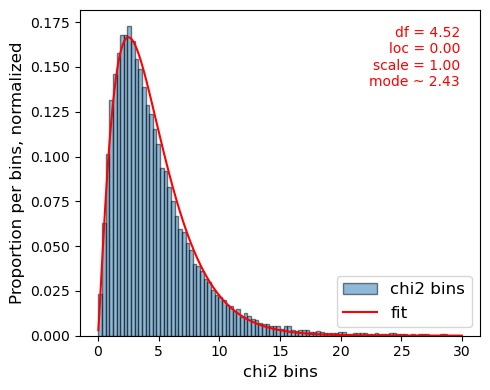

In [91]:
#--- Supposing a Chi2 dsitribution of the fitting parameter, compute the df of this distribution ---
%matplotlib inline
import scipy.stats as stats

# fitting dist
chi_star = final[(final["NBAND_USED"]==6) & (final["SCALE_STAR"]>1e-30)]["CHI_STAR"]
chi_star = chi_star[chi_star<30]

df, loc, scale = stats.chi2.fit(chi_star, floc=0, fscale=1.0)
x = np.linspace(min(chi_star), max(chi_star), 1000)
pdf = stats.chi2.pdf(x, df, loc, scale)

# plot
plt.figure(figsize=(5,4))
hst =plt.hist(chi_star, bins=100, density=True, alpha=0.5, edgecolor='black', label='chi2 bins')
plt.plot(x, pdf, 'r-', label='fit')

# add fit values
plt.text(0.95, 0.95,
    f"df = {df:.2f}\nloc = {loc:.2f}\nscale = {scale:.2f}\nmode ~ {hst[1][np.argmax(hst[0])]:.2f}",
    transform=plt.gca().transAxes,
    verticalalignment='top',
    horizontalalignment='right',
    c='r')

# #
# pdf2 = stats.chi2.pdf(x, 4.7, loc, scale)
# plt.plot(x, pdf2, 'b--', label='fit')
# plt.text(0.95, 0.65,
#     f"df = 4.43\nloc = {loc:.2f}\nscale = {scale:.2f}\nmode ~ {hst[1][np.argmax(hst[0])+1]:.2f}",
#     transform=plt.gca().transAxes,
#     verticalalignment='top',
#     horizontalalignment='right',
#     c='b')

#
# plt.ylim(0,1)
plt.xlabel("chi2 bins", fontsize = 12)
plt.ylabel("Proportion per bins, normalized", fontsize = 12)
plt.legend(fontsize = 12)
plt.tight_layout()
plt.show()


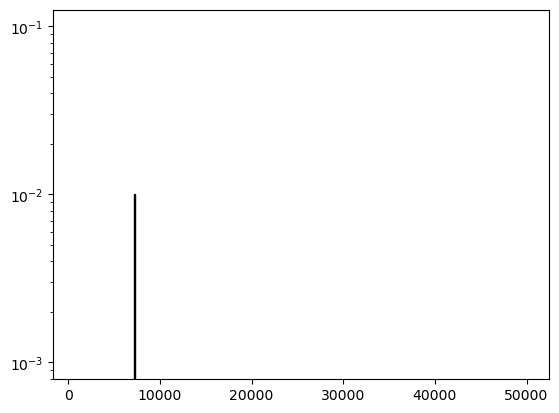

In [92]:
mask = (final["NBAND_USED"]==6) & (final["SCALE_STAR"]>1e-30)
beans = list(range(800, 12001, 100)) + list(range(13000, 20001, 1000)) + list(range(22000, 50001, 2000))
# beans = np.arange(0.0, 5.6, 0.5)
# beans = [-3, -2.5, -2, -1.5, -1, -0.5, 0.0, 0.3, 0.5]
plt.figure()
plt.hist(final[mask]["teff"],bins=beans,edgecolor='black',density=True,log=True)
plt.show()

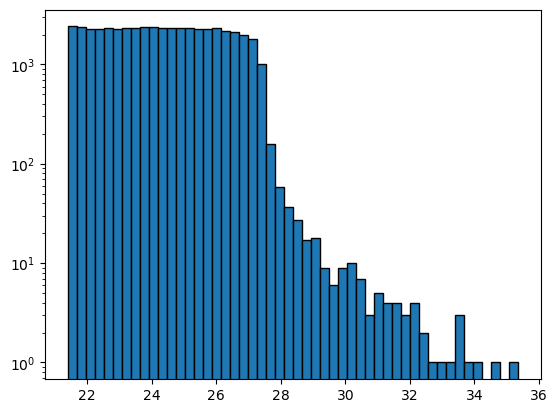

In [93]:
mask = (final["NBAND_USED"]==6) & (final["SCALE_STAR"]>1e-30)
plt.figure()
plt.hist(-2.5 * np.log10(final[mask]["SCALE_STAR"]),bins=50,edgecolor='black',density=False,log=True)
plt.show()

### 4.2 Compute our own chi2

In [94]:
def compute_chi2(df, bands = ['u','g','r','i','z','y'], plot_residu_stats=False, **r_stats_kwargs):

    #--- init ---
    chi2_array = np.zeros(len(df))
    N_used_array = df['N_filt'].values.copy()
        
    # ---vectorize over bands---
    for band in bands:
        # convert to flux
        obs = 10**(-0.4*df[f'magnitude_{band}'])
        true = 10**(-0.4*df[f'magnitude_{band}_true'])
        err = np.log(10)/2.5*obs*df[f'magnitude_{band}_err_sim']
        # obs = df[f'magnitude_{band}']
        # true = df[f'magnitude_{band}_true']
        # err = df[f'magnitude_{band}_err_sim']

        #delete nan columns
        valid_mask = obs.notna() & true.notna() & err.notna() & (err != 0)
        r = ((obs-true)/err).where(valid_mask, 0)
        
        if plot_residu_stats == True:
            pt.plot_r_stats(r, **r_stats_kwargs)

        #--- compute chi2 ---
        chi2_array += r**2


        #lower N_flit
        N_used_array -= (~valid_mask).astype(int)

    # Add columns to df
    df['chi2'] = chi2_array
    df['N_filt'] = N_used_array

    return df

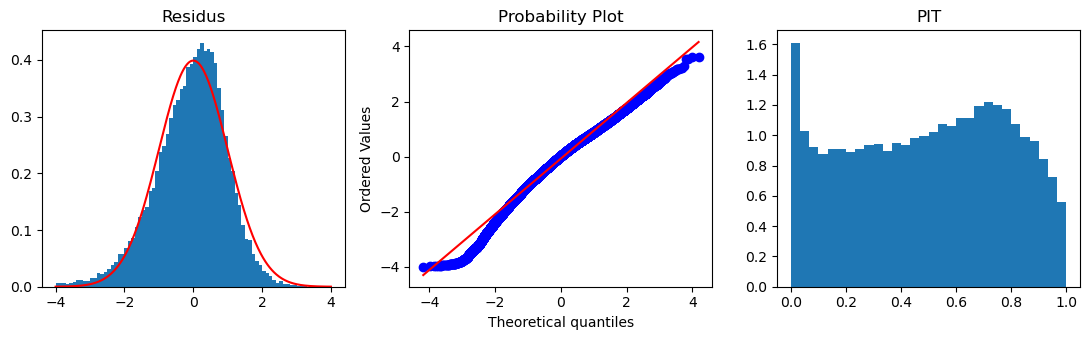

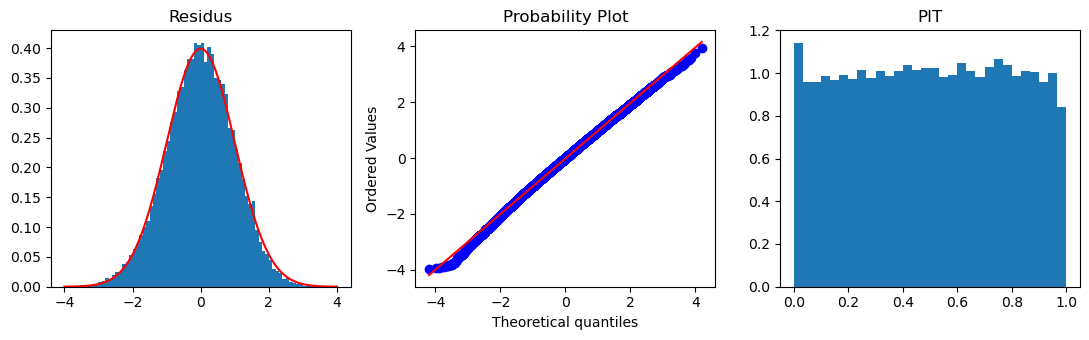

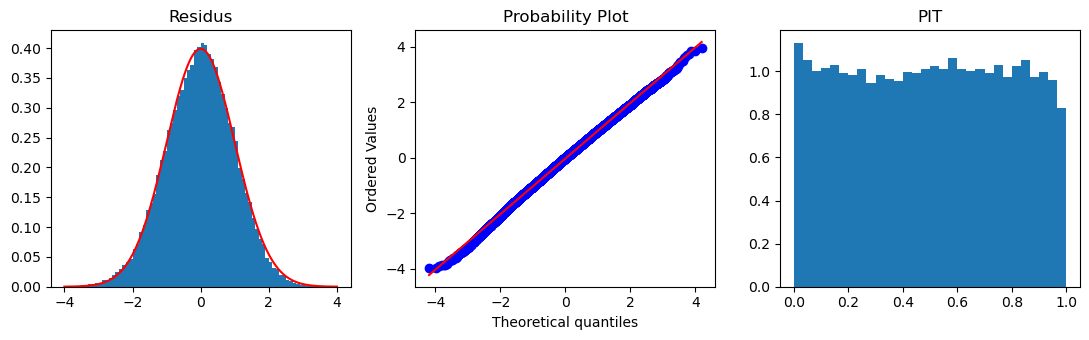

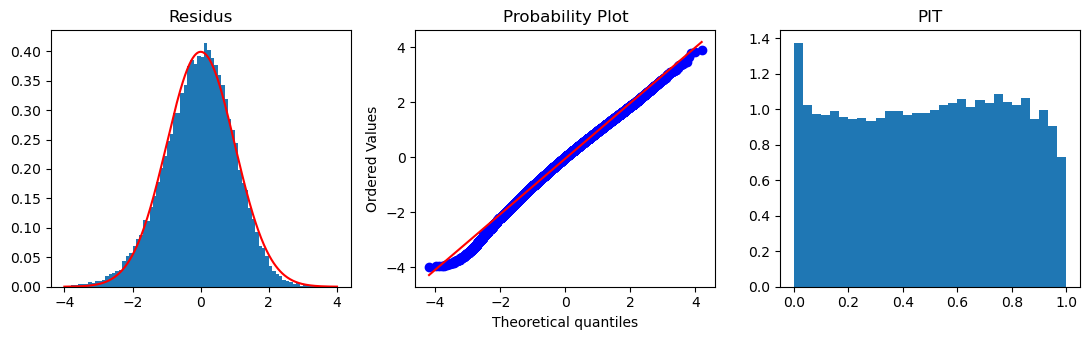

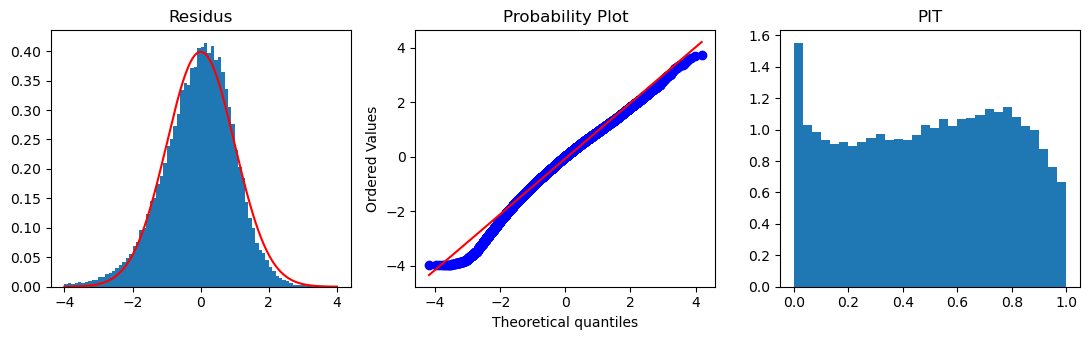

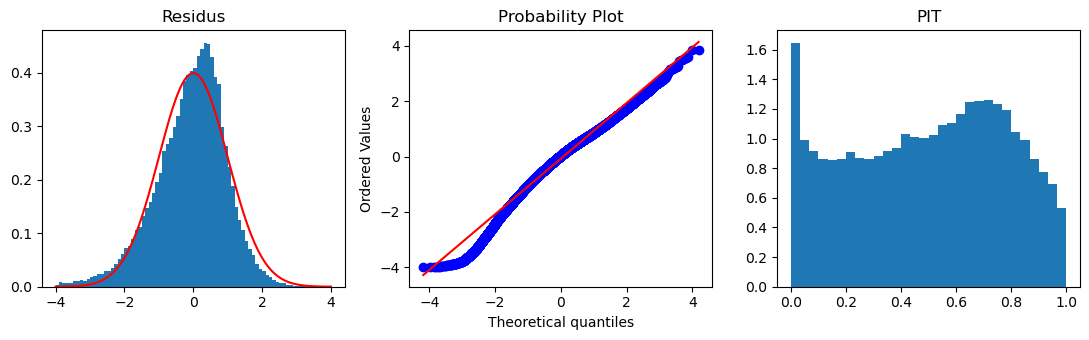

In [95]:
test = compute_chi2(mock_cat, bands = ['u','g','r','i','z','y'], plot_residu_stats=True, log=False, rrange=(-4,4), density=True)

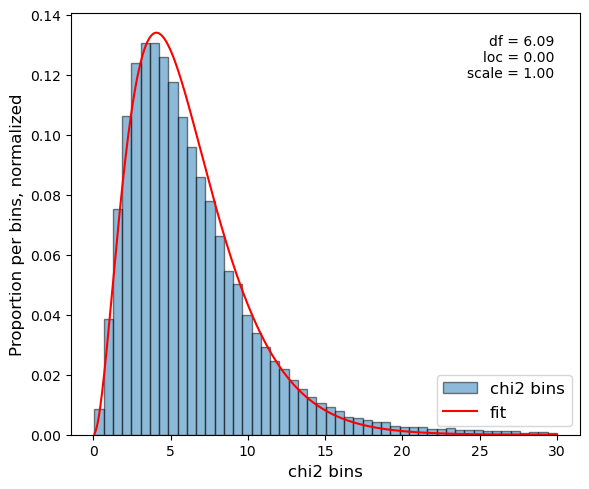

In [96]:
import scipy.stats as stats
%matplotlib inline

# fitting dist
chi_star = test[test["N_filt"]==6]["chi2"]#N_filt mask
chi_star = chi_star[chi_star<30]

df, loc, scale = stats.chi2.fit(chi_star, floc=0, fscale=1)
x = np.linspace(min(chi_star), max(chi_star), 1000)
pdf = stats.chi2.pdf(x, df, loc, scale)

# plot
plt.figure(figsize=(6,5))
plt.hist(chi_star, bins=50, density=True, alpha=0.5, edgecolor='black', label='chi2 bins')
plt.plot(x, pdf, 'r-', label='fit')

# add fit values
plt.text(0.95, 0.95,
    f"df = {df:.2f}\nloc = {loc:.2f}\nscale = {scale:.2f}",
    transform=plt.gca().transAxes,
    verticalalignment='top',
    horizontalalignment='right',)

#
# plt.ylim(0,1)
plt.xlabel("chi2 bins", fontsize = 12)
plt.ylabel("Proportion per bins, normalized", fontsize = 12)
plt.legend(fontsize = 12)
plt.tight_layout()
plt.show()

